# Confidence Analysis — Cyclic Dependency & Shared Database
Sum of raw confidence scores per model for the two smells with no (or near-zero) positives in the ground truth.

In [9]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results')

TARGET_SMELLS = ['cyclic_dependency', 'shared_database']
SMELL_LABELS  = {
    'cyclic_dependency': 'Cyclic Dep.',
    'shared_database':   'Shared DB',
}

MODEL_DISPLAY_NAMES = {
    'Llama-4-Maverick-17B-128E-Instruct-FP8-e81efef6': 'llama-4-maverick',
}

print('Setup done.')

Setup done.


In [10]:
# Load raw confidence scores for the two target smells

pred_rows = []

for run_file in sorted(RESULTS_DIR.rglob('run_*.json')):
    smell_dir = run_file.parent
    if smell_dir.name not in TARGET_SMELLS:
        continue
    sys_dir = smell_dir.parent
    m = re.match(r'^(\d+)', sys_dir.name)
    if not m:
        continue
    sys_id = m.group(1)
    raw_model = sys_dir.parent.name
    model_name = MODEL_DISPLAY_NAMES.get(raw_model, raw_model)

    with open(run_file) as f:
        data = json.load(f)
    confidence = data.get('confidence')
    if confidence is not None:
        pred_rows.append({
            'model':      model_name,
            'sys_id':     sys_id,
            'smell':      smell_dir.name,
            'run':        run_file.stem,
            'confidence': float(confidence),
        })

df = pd.DataFrame(pred_rows)
print(f"Rows loaded: {len(df)}")
print(f"Models : {sorted(df['model'].unique())}")
print(f"Smells : {sorted(df['smell'].unique())}")
print(f"Systems: {sorted(df['sys_id'].unique())}")

Rows loaded: 252
Models : ['claude-sonnet-4-6', 'gemini-2.5-pro', 'gemma-3n-E4B-it', 'gpt-5.3-codex', 'gpt-5.4', 'llama-4-maverick', 'qwen-vl-max']
Smells : ['cyclic_dependency', 'shared_database']
Systems: ['1', '2', '3', '4', '5', '6', '7', '8', '9']


In [11]:
# Sum of confidence per model × smell

conf_sum = (
    df.groupby(['model', 'smell'])['confidence']
    .sum()
    .reset_index()
    .rename(columns={'confidence': 'conf_sum'})
)

conf_pivot = (
    conf_sum
    .pivot(index='model', columns='smell', values='conf_sum')
    [TARGET_SMELLS]
    .rename(columns=SMELL_LABELS)
)
conf_pivot['Total'] = conf_pivot.sum(axis=1)
conf_pivot = conf_pivot.sort_values('Total', ascending=False)

print('=== Sum of confidence per model and smell ===')
display(conf_pivot)

=== Sum of confidence per model and smell ===


smell,Cyclic Dep.,Shared DB,Total
model,,,
gemma-3n-E4B-it,54.0,64.0,118.0
claude-sonnet-4-6,38.0,29.0,67.0
gpt-5.3-codex,36.0,28.0,64.0
gpt-5.4,34.0,27.0,61.0
llama-4-maverick,29.0,30.0,59.0
gemini-2.5-pro,32.0,24.0,56.0
qwen-vl-max,24.0,24.0,48.0


In [12]:
# Sum of confidence per model (both smells combined)

conf_total = (
    df.groupby('model')['confidence']
    .sum()
    .reset_index()
    .rename(columns={'confidence': 'conf_sum'})
    .sort_values('conf_sum', ascending=False)
)

print('=== Total confidence sum per model (Cyclic Dep. + Shared DB) ===')
display(conf_total.set_index('model'))

=== Total confidence sum per model (Cyclic Dep. + Shared DB) ===


,conf_sum
model,
gemma-3n-E4B-it,118.0
claude-sonnet-4-6,67.0
gpt-5.3-codex,64.0
gpt-5.4,61.0
llama-4-maverick,59.0
gemini-2.5-pro,56.0
qwen-vl-max,48.0


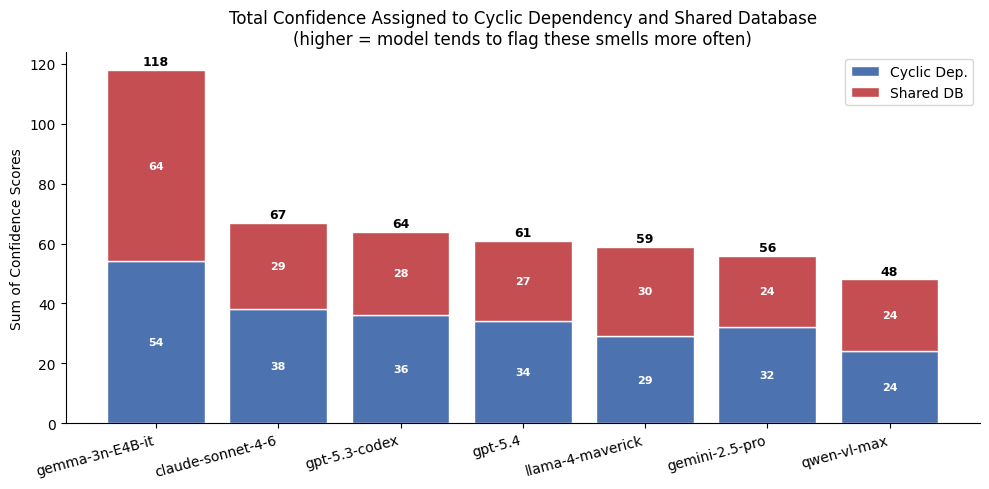

In [13]:
# Chart: stacked bar — confidence sum per model, split by smell

models     = conf_pivot.index.tolist()
cd_vals    = conf_pivot['Cyclic Dep.'].values
sd_vals    = conf_pivot['Shared DB'].values
x          = np.arange(len(models))
colors_bar = ['#4C72B0', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 5))
bars_cd = ax.bar(x, cd_vals, label='Cyclic Dep.', color=colors_bar[0], edgecolor='white')
bars_sd = ax.bar(x, sd_vals, bottom=cd_vals, label='Shared DB',   color=colors_bar[1], edgecolor='white')

for bar, val in zip(bars_cd, cd_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                f'{val:.0f}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

for bar, base, val in zip(bars_sd, cd_vals, sd_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, base + val / 2,
                f'{val:.0f}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

for i, total in enumerate(conf_pivot['Total'].values):
    ax.text(i, total + 0.5, f'{total:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Sum of Confidence Scores')
ax.set_title('Total Confidence Assigned to Cyclic Dependency and Shared Database\n(higher = model tends to flag these smells more often)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('confidence_sum_cd_sd.png', dpi=150)
plt.show()

In [14]:
# Breakdown per system: which systems drove the highest confidence?

sys_conf = (
    df.groupby(['smell', 'sys_id'])['confidence']
    .sum()
    .reset_index()
    .rename(columns={'confidence': 'conf_sum'})
)

sys_pivot = (
    sys_conf
    .pivot(index='sys_id', columns='smell', values='conf_sum')
    [TARGET_SMELLS]
    .rename(columns=SMELL_LABELS)
    .fillna(0)
)
sys_pivot['Total'] = sys_pivot.sum(axis=1)
sys_pivot = sys_pivot.sort_values('Total', ascending=False)

print('=== Confidence sum per system (all models combined) ===')
display(sys_pivot)

=== Confidence sum per system (all models combined) ===


smell,Cyclic Dep.,Shared DB,Total
sys_id,,,
5,44.0,29.0,73.0
6,42.0,29.0,71.0
1,25.0,33.0,58.0
9,26.0,30.0,56.0
4,24.0,22.0,46.0
3,24.0,21.0,45.0
7,20.0,24.0,44.0
2,20.0,20.0,40.0
8,22.0,18.0,40.0


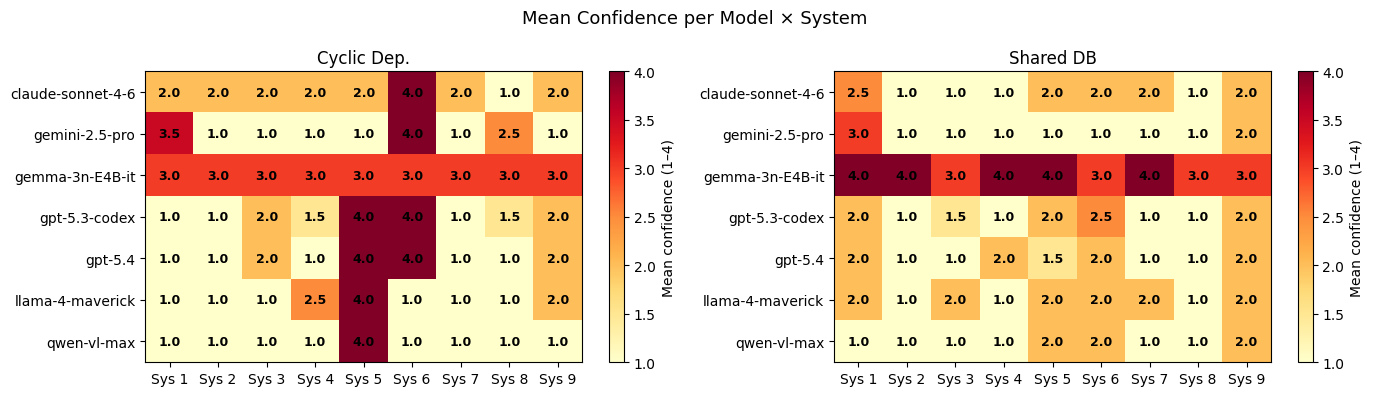

In [15]:
# Heatmap: mean confidence per model × system for each smell

mean_conf = (
    df.groupby(['smell', 'model', 'sys_id'])['confidence']
    .mean()
    .reset_index()
    .rename(columns={'confidence': 'mean_conf'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, smell in zip(axes, TARGET_SMELLS):
    pivot = (
        mean_conf[mean_conf['smell'] == smell]
        .pivot(index='model', columns='sys_id', values='mean_conf')
    )
    im = ax.imshow(pivot.values.astype(float), cmap='YlOrRd', vmin=1, vmax=4, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'Sys {s}' for s in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            ax.text(c, r, f'{val:.1f}' if not np.isnan(val) else '-',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Mean confidence (1–4)')
    ax.set_title(SMELL_LABELS[smell])

fig.suptitle('Mean Confidence per Model × System', fontsize=13)
plt.tight_layout()
plt.savefig('confidence_heatmap_cd_sd.png', dpi=150)
plt.show()

In [16]:
THRESHOLD = 3

# All individual runs where the model flagged the smell as present (confidence >= threshold)

detections = (
    df[df['confidence'] >= THRESHOLD]
    .sort_values(['smell', 'model', 'sys_id', 'run'])
    [['smell', 'model', 'sys_id', 'run', 'confidence']]
    .rename(columns={
        'smell':      'Smell',
        'model':      'Model',
        'sys_id':     'System',
        'run':        'Run',
        'confidence': 'Confidence',
    })
    .reset_index(drop=True)
)

print(f"Total detections (confidence >= {THRESHOLD}): {len(detections)}")
print()
display(detections)

print()
print('=== Detection count per model × smell ===')
display(
    detections.groupby(['Smell', 'Model'])
    .size()
    .rename('Detections')
    .reset_index()
    .pivot(index='Model', columns='Smell', values='Detections')
    .fillna(0)
    .astype(int)
)

Total detections (confidence >= 3): 61



,Smell,Model,System,Run,Confidence
0,cyclic_dependency,claude-sonnet-4-6,6,run_20260421_190618,4.0
1,cyclic_dependency,claude-sonnet-4-6,6,run_20260421_193424,4.0
2,cyclic_dependency,gemini-2.5-pro,1,run_20260421_195712,4.0
3,cyclic_dependency,gemini-2.5-pro,1,run_20260421_200719,3.0
4,cyclic_dependency,gemini-2.5-pro,6,run_20260421_195712,4.0
...,...,...,...,...,...
56,shared_database,gemma-3n-E4B-it,8,run_20260424_103607,3.0
57,shared_database,gemma-3n-E4B-it,8,run_20260424_104807,3.0
58,shared_database,gemma-3n-E4B-it,9,run_20260424_103607,3.0
59,shared_database,gemma-3n-E4B-it,9,run_20260424_104807,3.0



=== Detection count per model × smell ===


Smell,cyclic_dependency,shared_database
Model,,
claude-sonnet-4-6,2,1
gemini-2.5-pro,5,3
gemma-3n-E4B-it,18,18
gpt-5.3-codex,4,1
gpt-5.4,4,0
llama-4-maverick,3,0
qwen-vl-max,2,0


## Analysis 3 — Confidence Level of False Positives
Since the ground truth has no positives for either smell, every detection (confidence ≥ 3) is a false positive.  
Here we separate **borderline FPs** (confidence = 3, "probably present") from **high-confidence FPs** (confidence = 4, "definitely present").

In [17]:
# Breakdown by confidence level (3 = borderline, 4 = high-confidence)

detections['Confidence Level'] = detections['Confidence'].apply(
    lambda c: 'High (4)' if c == 4 else 'Borderline (3)'
)

conf_level_summary = (
    detections.groupby(['Smell', 'Model', 'Confidence Level'])
    .size()
    .rename('Count')
    .reset_index()
)

conf_level_pivot = (
    detections.groupby(['Model', 'Confidence Level'])
    .size()
    .rename('Count')
    .reset_index()
    .pivot(index='Model', columns='Confidence Level', values='Count')
    .fillna(0)
    .astype(int)
    .assign(Total=lambda d: d.sum(axis=1))
    .sort_values('Total', ascending=False)
)

print('=== FP count by confidence level per model (both smells combined) ===')
display(conf_level_pivot)

print()
print('=== FP count by confidence level per model × smell ===')
display(
    detections.groupby(['Smell', 'Model', 'Confidence Level'])
    .size()
    .rename('Count')
    .reset_index()
    .pivot_table(index=['Smell', 'Model'], columns='Confidence Level', values='Count', fill_value=0)
    .astype(int)
)

=== FP count by confidence level per model (both smells combined) ===


Confidence Level,Borderline (3),High (4),Total
Model,,,
gemma-3n-E4B-it,26,10,36
gemini-2.5-pro,4,4,8
gpt-5.3-codex,1,4,5
gpt-5.4,0,4,4
claude-sonnet-4-6,1,2,3
llama-4-maverick,1,2,3
qwen-vl-max,0,2,2



=== FP count by confidence level per model × smell ===


Confidence Level                     Borderline (3)  High (4)
Smell             Model                                      
cyclic_dependency claude-sonnet-4-6               0         2
                  gemini-2.5-pro                  1         4
                  gemma-3n-E4B-it                18         0
                  gpt-5.3-codex                   0         4
                  gpt-5.4                         0         4
                  llama-4-maverick                1         2
                  qwen-vl-max                     0         2
shared_database   claude-sonnet-4-6               1         0
                  gemini-2.5-pro                  3         0
                  gemma-3n-E4B-it                 8        10
                  gpt-5.3-codex                   1         0

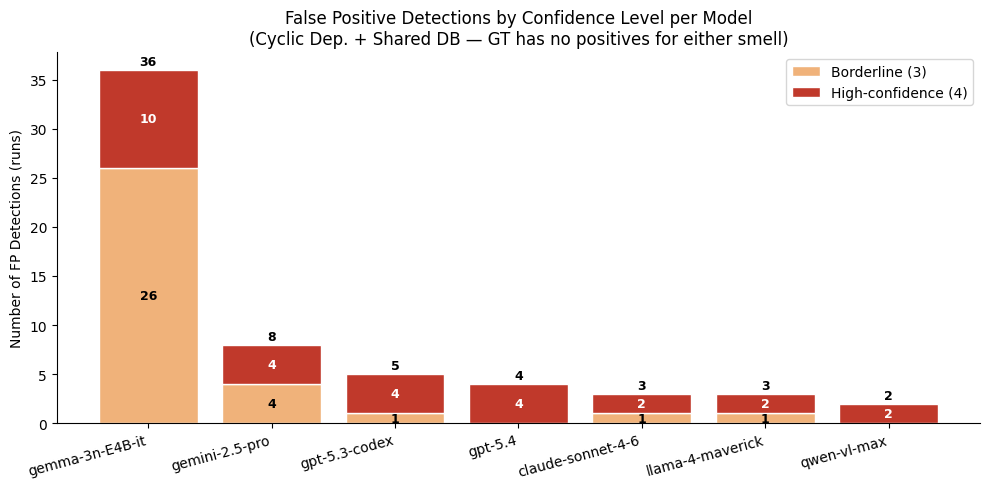

In [18]:
# Chart: stacked bar — Borderline vs High-confidence FPs per model

models_fp  = conf_level_pivot.index.tolist()
borderline = conf_level_pivot.get('Borderline (3)', pd.Series(0, index=models_fp)).values
high       = conf_level_pivot.get('High (4)',       pd.Series(0, index=models_fp)).values
x          = np.arange(len(models_fp))

fig, ax = plt.subplots(figsize=(10, 5))
bars_b = ax.bar(x, borderline, label='Borderline (3)', color='#F0B27A', edgecolor='white')
bars_h = ax.bar(x, high, bottom=borderline, label='High-confidence (4)', color='#C0392B', edgecolor='white')

for bar, val in zip(bars_b, borderline):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, val / 2,
                str(int(val)), ha='center', va='center', fontsize=9, fontweight='bold')

for bar, base, val in zip(bars_h, borderline, high):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, base + val / 2,
                str(int(val)), ha='center', va='center', fontsize=9, fontweight='bold', color='white')

for i, total in enumerate(borderline + high):
    if total > 0:
        ax.text(i, total + 0.2, str(int(total)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_fp, rotation=15, ha='right')
ax.set_ylabel('Number of FP Detections (runs)')
ax.set_title('False Positive Detections by Confidence Level per Model\n(Cyclic Dep. + Shared DB — GT has no positives for either smell)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fp_confidence_level.png', dpi=150)
plt.show()

## Analysis 4 — Model FP Profile
Which models generate more FPs? Do they flag the same systems or different ones?  
**Systematic bias**: model consistently flags the same systems → likely misunderstanding the smell definition.  
**Noisy behavior**: model flags different systems across runs → likely hallucination/uncertainty.

In [19]:
profile = (
    detections.groupby('Model')
    .agg(
        FP_runs    =('Run',    'count'),
        Unique_sys =('System', 'nunique'),
    )
    .assign(Runs_per_sys=lambda d: (d['FP_runs'] / d['Unique_sys']).round(2))
    .sort_values('FP_runs', ascending=False)
)

print('=== Model FP profile ===')
print('(Runs_per_sys > 1 → same systems flagged repeatedly = systematic bias)')
display(profile)

print()
print('=== Systems flagged per model (set) ===')
for model, grp in detections.groupby('Model'):
    systems = sorted(grp['System'].unique())
    print(f"  {model:30s}: {systems}")

=== Model FP profile ===
(Runs_per_sys > 1 → same systems flagged repeatedly = systematic bias)


,FP_runs,Unique_sys,Runs_per_sys
Model,,,
gemma-3n-E4B-it,36,9,4.0
gemini-2.5-pro,8,4,2.0
gpt-5.3-codex,5,2,2.5
gpt-5.4,4,2,2.0
claude-sonnet-4-6,3,2,1.5
llama-4-maverick,3,2,1.5
qwen-vl-max,2,1,2.0



=== Systems flagged per model (set) ===
  claude-sonnet-4-6             : ['1', '6']
  gemini-2.5-pro                : ['1', '6', '8', '9']
  gemma-3n-E4B-it               : ['1', '2', '3', '4', '5', '6', '7', '8', '9']
  gpt-5.3-codex                 : ['5', '6']
  gpt-5.4                       : ['5', '6']
  llama-4-maverick              : ['4', '5']
  qwen-vl-max                   : ['5']


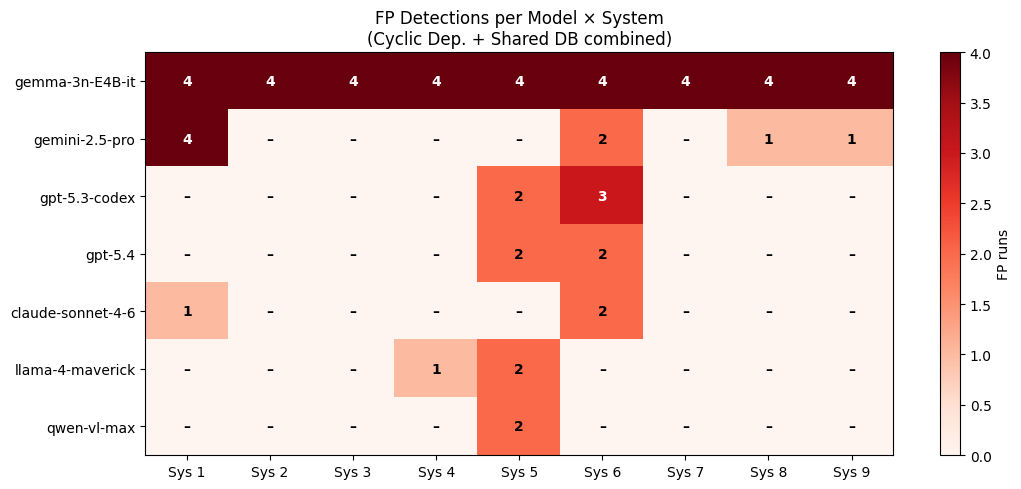

In [20]:
# Heatmap: number of FP runs per model × system (both smells combined)
# Reveals which model–system pairs are most problematic

fp_heat = (
    detections.groupby(['Model', 'System'])
    .size()
    .rename('FP_runs')
    .reset_index()
    .pivot(index='Model', columns='System', values='FP_runs')
    .fillna(0)
    .astype(int)
)

all_systems = sorted(df['sys_id'].unique())
fp_heat = fp_heat.reindex(columns=all_systems, fill_value=0)
fp_heat = fp_heat.loc[fp_heat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(fp_heat.values.astype(float), cmap='Reds', vmin=0, aspect='auto')

ax.set_xticks(range(len(fp_heat.columns)))
ax.set_xticklabels([f'Sys {s}' for s in fp_heat.columns])
ax.set_yticks(range(len(fp_heat.index)))
ax.set_yticklabels(fp_heat.index)

for r in range(fp_heat.shape[0]):
    for c in range(fp_heat.shape[1]):
        val = fp_heat.values[r, c]
        ax.text(c, r, str(val) if val > 0 else '–',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if val >= fp_heat.values.max() * 0.6 else 'black')

plt.colorbar(im, ax=ax, label='FP runs')
ax.set_title('FP Detections per Model × System\n(Cyclic Dep. + Shared DB combined)')
plt.tight_layout()
plt.savefig('fp_model_system_heatmap.png', dpi=150)
plt.show()